# Population Health & Care Gap Analysis

Uses the same parsed FHIR tables to answer population-health questions: who's in this
population, what conditions are most prevalent, and, as a concrete care-gap example,
which diabetic patients are missing a recent HbA1c lab test (a standard quality measure
in real EHR/population-health tooling).

**Data source:** `data/processed/*.csv`, produced by `parse_fhir_bundles.py`.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

In [13]:
DATA_DIR = '../data/processed'

patients = pd.read_csv(f'{DATA_DIR}/patients.csv')
conditions = pd.read_csv(f'{DATA_DIR}/conditions.csv')
observations = pd.read_csv(f'{DATA_DIR}/observations.csv', parse_dates=['effective_date'])
observations['effective_date'] = pd.to_datetime(observations['effective_date'], errors='coerce', utc=True).dt.tz_localize(None)
immunizations = pd.read_csv(f'{DATA_DIR}/immunizations.csv')
medication_requests = pd.read_csv(f'{DATA_DIR}/medication_requests.csv')

patients['birth_date'] = pd.to_datetime(patients['birth_date'])
print(f"Patients: {len(patients):,}")

Patients: 555


## 1. Population overview

Reference date (latest activity in dataset): 2021-11-18

Gender distribution:
gender
female    302
male      253
Name: count, dtype: int64

Age summary:
count   555.0
mean     42.2
std      25.7
min       0.0
25%      21.0
50%      41.0
75%      60.0
max     110.0
Name: age, dtype: float64


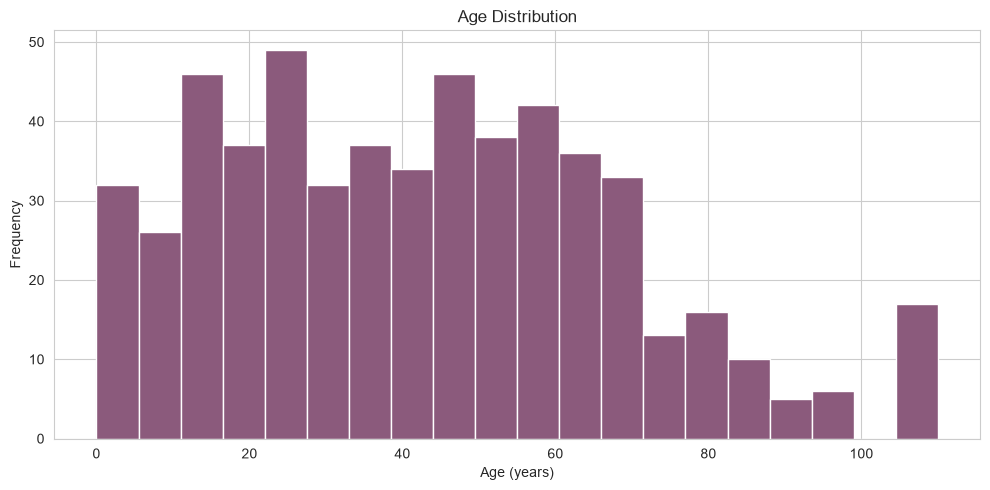

In [14]:
# This is historical synthetic data, not real people today — compute age as of
# the latest date seen anywhere in the dataset, not today's date.
as_of = observations['effective_date'].max()
patients['age'] = ((as_of - patients['birth_date']).dt.days / 365.25).round(0)

print(f'Reference date (latest activity in dataset): {as_of.date()}')
print(f"\nGender distribution:\n{patients['gender'].value_counts()}")
print(f"\nAge summary:\n{patients['age'].describe().round(1)}")

fig, ax = plt.subplots(figsize=(10, 5))
patients['age'].plot(kind='hist', bins=20, ax=ax, color='#8B5A7C')
ax.set_title('Age Distribution')
ax.set_xlabel('Age (years)')
plt.tight_layout()
plt.show()

In [15]:
print("Top 10 states by patient count:")
patients['state'].value_counts().head(10)

Top 10 states by patient count:


state
MA    555
Name: count, dtype: int64

## 2. Chronic disease prevalence

Prevalence = number of *unique patients* with the condition, divided by the total
patient population- not raw row counts (a patient can have the same condition logged
at multiple encounters).

In [16]:
total_patients = patients['patient_id'].nunique()

condition_prevalence = (
    conditions.groupby('code_display')['patient_id']
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)
condition_prevalence_pct = (condition_prevalence / total_patients * 100).round(1)

pd.DataFrame({
    'unique_patients': condition_prevalence,
    '% of population': condition_prevalence_pct,
})

,unique_patients,% of population
code_display,,
Stress (finding),416,75.0
Full-time employment (finding),389,70.1
Viral sinusitis (disorder),351,63.2
Part-time employment (finding),318,57.3
Social isolation (finding),300,54.1
Limited social contact (finding),296,53.3
Received higher education (finding),257,46.3
Acute viral pharyngitis (disorder),252,45.4
Not in labor force (finding),226,40.7


## 3. Medication burden

How many distinct medications has each patient been prescribed, across their whole
record? A simple polypharmacy signal: patients with a high count are worth a closer
look in a real chart review.

In [17]:
meds_per_patient = medication_requests.groupby('patient_id')['code'].nunique()

print(meds_per_patient.describe().round(1))
print(f"\nPatients with 5+ distinct medications on record: {(meds_per_patient >= 5).sum():,} ({(meds_per_patient >= 5).mean() * 100:.1f}%)")

count   535.0
mean      4.9
std       3.0
min       0.0
25%       3.0
50%       4.0
75%       7.0
max      15.0
Name: code, dtype: float64

Patients with 5+ distinct medications on record: 260 (48.6%)


## 4. Care gap example: diabetics without a recent HbA1c

Standard quality measure: diabetic patients should get an HbA1c lab (LOINC 4548-4,
"Hemoglobin A1c/Hemoglobin.total in Blood") roughly every 6-12 months. Here we flag
diabetic patients with **no HbA1c observation at all in the trailing 12 months** of the
dataset's own timeline (not calendar-today, since this is historical synthetic data).

In [18]:
# Identify diabetic patients by condition display text (catches all diabetes
# variants/subtypes synthea generates, not just one exact code).
diabetic_condition_mask = conditions['code_display'].str.contains('diabetes', case=False, na=False)
diabetic_patients = set(conditions.loc[diabetic_condition_mask, 'patient_id'])
print(f'Diabetic patients identified: {len(diabetic_patients):,} ({len(diabetic_patients) / total_patients * 100:.1f}% of population)')

conditions.loc[diabetic_condition_mask, 'code_display'].value_counts()

Diabetic patients identified: 165 (29.7% of population)


code_display
Prediabetes                                                                         155
Diabetes                                                                             32
Neuropathy due to type 2 diabetes mellitus (disorder)                                 9
Diabetic retinopathy associated with type II diabetes mellitus (disorder)             8
Nonproliferative diabetic retinopathy due to type 2 diabetes mellitus (disorder)      5
Macular edema and retinopathy due to type 2 diabetes mellitus (disorder)              2
Proliferative diabetic retinopathy due to type II diabetes mellitus (disorder)        1
Microalbuminuria due to type 2 diabetes mellitus (disorder)                           1
Name: count, dtype: int64

In [19]:
# Identify HbA1c observations by LOINC code first, falling back to display text
# in case any records used a different coding system.
a1c_mask = (
    (observations['code'] == '4548-4')
    | observations['code_display'].str.contains('a1c|hemoglobin a1c', case=False, na=False)
)
a1c_obs = observations.loc[a1c_mask].copy()
print(f'Total HbA1c observations found: {len(a1c_obs):,}')

window_start = as_of - pd.Timedelta(days=365)
recent_a1c = a1c_obs[a1c_obs['effective_date'] >= window_start]
patients_with_recent_a1c = set(recent_a1c['patient_id'])

diabetics_missing_a1c = diabetic_patients - patients_with_recent_a1c

print(f"\nDiabetic patients: {len(diabetic_patients):,}")
print(f"Diabetic patients WITH an HbA1c in the trailing 12 months: {len(diabetic_patients & patients_with_recent_a1c):,}")
print(f"Diabetic patients MISSING a recent HbA1c (care gap): {len(diabetics_missing_a1c):,} ({len(diabetics_missing_a1c) / max(len(diabetic_patients), 1) * 100:.1f}% of diabetics)")

Total HbA1c observations found: 1,874

Diabetic patients: 165
Diabetic patients WITH an HbA1c in the trailing 12 months: 127
Diabetic patients MISSING a recent HbA1c (care gap): 38 (23.0% of diabetics)


## 5. Immunization coverage
What share of the population has each vaccine on record at all?

In [20]:
immunization_coverage = (
    immunizations.groupby('code_display')['patient_id']
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)
immunization_coverage_pct = (immunization_coverage / total_patients * 100).round(1)

pd.DataFrame({
    'unique_patients': immunization_coverage,
    '% of population': immunization_coverage_pct,
})

,unique_patients,% of population
code_display,,
"Influenza, seasonal, injectable, preservative free",547,98.6
Td (adult) preservative free,381,68.6
"SARS-COV-2 (COVID-19) vaccine, mRNA, spike protein, LNP, preservative free, 30 mcg/0.3mL dose",189,34.1
meningococcal MCV4P,150,27.0
"SARS-COV-2 (COVID-19) vaccine, mRNA, spike protein, LNP, preservative free, 100 mcg/0.5mL dose",126,22.7
Pneumococcal conjugate PCV 13,104,18.7
IPV,94,16.9
"HPV, quadrivalent",90,16.2
DTaP,90,16.2


## Key findings

- 555 patients, 54% female / 46% male, ages 0–110 (mean 42). All patients are located
  in Massachusetts, which reflects how Synthea's sample population was built rather
  than a data issue.
  
- The most common conditions are viral sinusitis (63.2%), prediabetes (27.9%),
  hypertension (25.4%), and obesity (37.7%). Synthea also models social factors, and
  several show up heavily here: stress (75%), social isolation (54.1%), and
  unemployment (57.3% part-time, 40.7% not in the labor force).

  
- Patients average 4.9 distinct medications, and 48.6% are on 5 or more — a
  polypharmacy rate worth a closer look in a real chart review.

  
- 165 patients (29.7%) are diabetic or prediabetic. Of those with an active diabetes
  diagnosis, 23% (38 of 165) have no HbA1c lab result in the past 12 months, a
  standard diabetes-management quality measure. In a real population-health program,
  this group would be the outreach target.

  
- Flu vaccine coverage is 98.6%, nearly universal. Childhood vaccines (MMR, varicella,
  HPV) sit around 15% coverage, which reflects the mixed-age population rather than
  an actual gap.